# ECON 570 Final Project
## Title: Financial Market Reactions to FOMC Monetary Policy Announcements
## Group N
## Yaqiao Zhang, Wilbur Su

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

## Data Cleaning

In [2]:
#load csv from FRED
def load_fred(path, name):
    df = pd.read_csv(path)
    df['DATE'] = pd.to_datetime(df['observation_date']) #Converts DATE variable to datetime
    df = df.rename(columns={df.columns[1]: name})
    df = df.set_index('DATE').sort_index() #Sets DATE as index for time-series merging
    return df

sp500 = load_fred('../final/data/SP500.csv', 'sp500')
dff   = load_fred('../final/data/DFF.csv',   'dff')
vix   = load_fred('../final/data/VIXCLS.csv',   'vix')
dgs10 = load_fred('../final/data/DGS10.csv', 'dgs10')
dtb3  = load_fred('../final/data/DTB3.csv',  'dtb3')
cpi   = load_fred('../final/data/CPIAUCSL.csv',   'cpi')
# Drop duplicate observation date column after cleaning
sp500 = sp500.drop(columns=['observation_date'])
dff   = dff.drop(columns=['observation_date'])
vix   = vix.drop(columns=['observation_date'])
dgs10 = dgs10.drop(columns=['observation_date'])
dtb3  = dtb3.drop(columns=['observation_date'])
cpi   = cpi.drop(columns=['observation_date'])

In [3]:
sp500.head()

,sp500
DATE,
2016-01-04,2012.66
2016-01-05,2016.71
2016-01-06,1990.26
2016-01-07,1943.09
2016-01-08,1922.03


In [4]:
# Combine all market variables into a single daily dataframe
daily = sp500.join([dff, vix, dgs10, dtb3], how='inner')
print(daily.shape)
daily.head()

(2589, 5)


,sp500,dff,vix,dgs10,dtb3
DATE,,,,,
2016-01-04,2012.66,0.36,20.70,2.24,0.22
2016-01-05,2016.71,0.36,19.34,2.25,0.20
2016-01-06,1990.26,0.36,20.59,2.18,0.21
2016-01-07,1943.09,0.36,24.99,2.16,0.20
2016-01-08,1922.03,0.36,27.01,2.13,0.20


In [5]:
# CPI is monthly, convert to daily frequency
cpi_daily = cpi.resample('D').ffill()
daily = daily.join(cpi_daily, how='left')
daily['cpi'] = daily['cpi'].ffill() 
daily.head()

,sp500,dff,vix,dgs10,dtb3,cpi
DATE,,,,,,
2016-01-04,2012.66,0.36,20.70,2.24,0.22,237.652
2016-01-05,2016.71,0.36,19.34,2.25,0.20,237.652
2016-01-06,1990.26,0.36,20.59,2.18,0.21,237.652
2016-01-07,1943.09,0.36,24.99,2.16,0.20,237.652
2016-01-08,1922.03,0.36,27.01,2.13,0.20,237.652


In [6]:
daily['ret'] = np.log(daily['sp500']).diff()# Compute daily log returns for S&P500
daily['d_dff'] = daily['dff'].diff()# Daily change in federal funds rate
daily['term_spread'] = daily['dgs10'] - daily['dtb3']# Term spread: 10-year minus 3-month Treasury rate
daily=daily.dropna()

In [7]:
daily.head()

,sp500,dff,vix,dgs10,dtb3,cpi,ret,d_dff,term_spread
DATE,,,,,,,,,
2016-01-05,2016.71,0.36,19.34,2.25,0.20,237.652,0.002010,0.0,2.05
2016-01-06,1990.26,0.36,20.59,2.18,0.21,237.652,-0.013202,0.0,1.97
2016-01-07,1943.09,0.36,24.99,2.16,0.20,237.652,-0.023986,0.0,1.96
2016-01-08,1922.03,0.36,27.01,2.13,0.20,237.652,-0.010898,0.0,1.93
2016-01-11,1923.67,0.36,24.30,2.17,0.21,237.652,0.000853,0.0,1.96


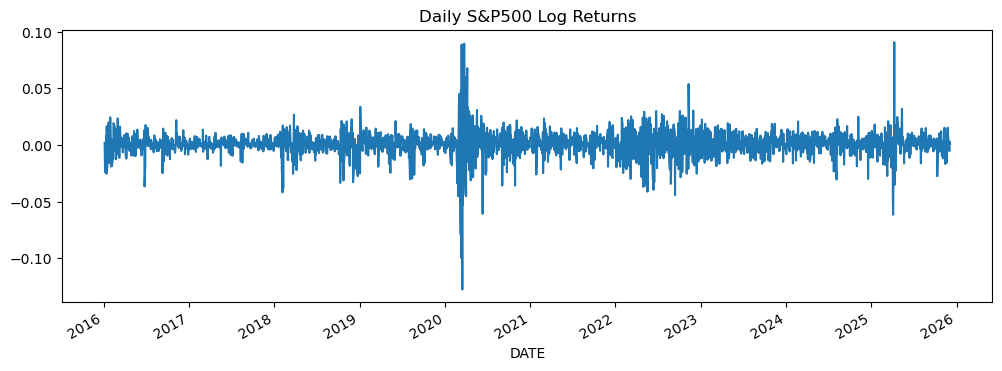

In [8]:
daily['ret'].plot(figsize=(12,4), title='Daily S&P500 Log Returns')
plt.show()

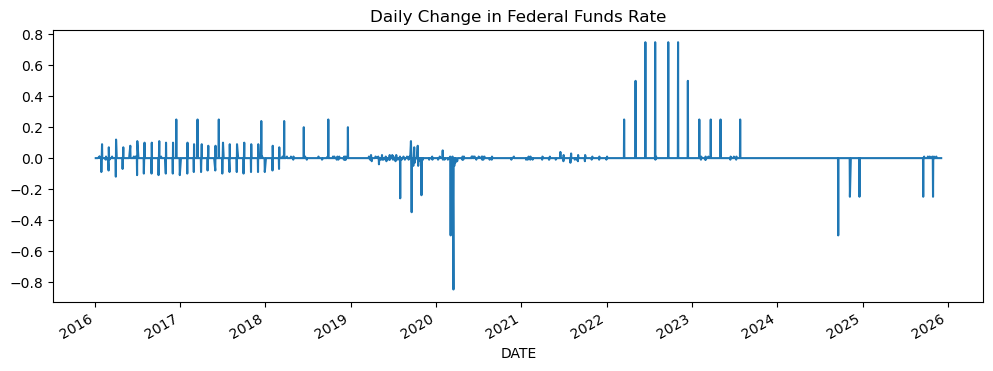

In [9]:
daily['d_dff'].plot(figsize=(12,4), title='Daily Change in Federal Funds Rate')
plt.show()

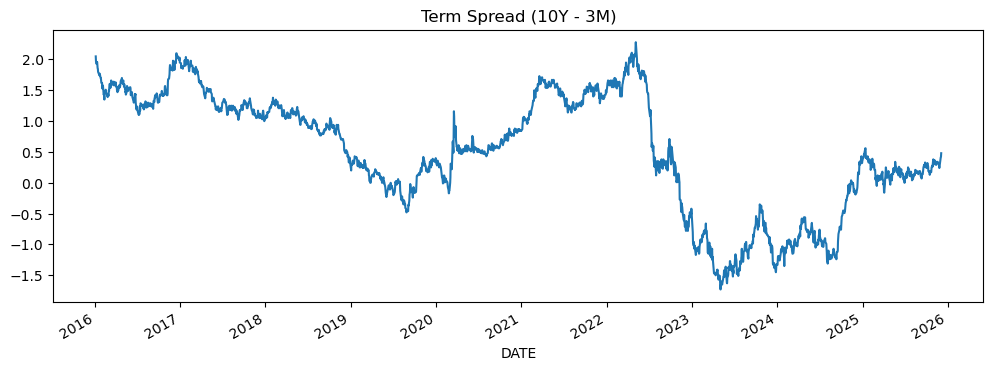

In [10]:
daily['term_spread'].plot(figsize=(12,4), title='Term Spread (10Y - 3M)')
plt.show()

In [11]:
fomc = pd.read_excel('../final/data/FOMC_Meetings.xlsx')
fomc.head()

,Year,Month,Meeting_Dates,Decision_Date,Action,Change_bps,Target_Range_Low,Target_Range_High,Notes
0,2015,January,Jan 27-28,2015-01-28,Hold,0.0,0.0,0.25,NaN
1,2015,March,Mar 17-18,2015-03-18,Hold,0.0,0.0,0.25,SEP Released
2,2015,April,Apr 28-29,2015-04-29,Hold,0.0,0.0,0.25,NaN
3,2015,June,Jun 16-17,2015-06-17,Hold,0.0,0.0,0.25,SEP Released
4,2015,July,Jul 28-29,2015-07-29,Hold,0.0,0.0,0.25,NaN


In [12]:
# Convert decision dates to datetime
# Extract all unique announcement event dates
fomc['Decision_Date'] = pd.to_datetime(fomc['Decision_Date'])
event_dates = fomc['Decision_Date'].sort_values().unique()

In [13]:
fomc.head()

,Year,Month,Meeting_Dates,Decision_Date,Action,Change_bps,Target_Range_Low,Target_Range_High,Notes
0,2015,January,Jan 27-28,2015-01-28,Hold,0.0,0.0,0.25,NaN
1,2015,March,Mar 17-18,2015-03-18,Hold,0.0,0.0,0.25,SEP Released
2,2015,April,Apr 28-29,2015-04-29,Hold,0.0,0.0,0.25,NaN
3,2015,June,Jun 16-17,2015-06-17,Hold,0.0,0.0,0.25,SEP Released
4,2015,July,Jul 28-29,2015-07-29,Hold,0.0,0.0,0.25,NaN


# Event Study

In [14]:
window = 2 #event window length [-2,+2]

event_list = []

for event_date in fomc['Decision_Date']:
    days = pd.date_range(event_date - pd.Timedelta(days=window),
                         event_date + pd.Timedelta(days=window),
                         freq='D')
    
    temp = pd.DataFrame({
        'DATE': days,
        'event_date': event_date,
        'event_time': (days - event_date).days
    })
    
    #Merge daily market data into event window
    temp = temp.merge(daily, left_on='DATE', right_index=True, how='left')
    
    #Merge FOMC metadata
    temp = temp.merge(
        fomc[['Decision_Date', 'Action', 'Change_bps']],
        left_on='event_date', right_on='Decision_Date',
        how='left'
    )
    
    event_list.append(temp)

event_df = pd.concat(event_list)
event_df = event_df.dropna(subset=['sp500'])# Remove non-trading days

event_df.head()


,DATE,event_date,event_time,sp500,dff,vix,dgs10,dtb3,cpi,ret,d_dff,term_spread,Decision_Date,Action,Change_bps
0,2016-01-25,2016-01-27,-2,1877.08,0.38,24.15,2.03,0.31,237.652,-0.015762,0.00,1.72,2016-01-27,Hold,0.0
1,2016-01-26,2016-01-27,-1,1903.63,0.38,22.50,2.01,0.31,237.652,0.014045,0.00,1.70,2016-01-27,Hold,0.0
2,2016-01-27,2016-01-27,0,1882.95,0.38,23.11,2.02,0.32,237.652,-0.010923,0.00,1.70,2016-01-27,Hold,0.0
3,2016-01-28,2016-01-27,1,1893.36,0.38,22.42,2.00,0.34,237.652,0.005513,0.00,1.66,2016-01-27,Hold,0.0
4,2016-01-29,2016-01-27,2,1940.24,0.29,20.20,1.94,0.32,237.652,0.024459,-0.09,1.62,2016-01-27,Hold,0.0


## RQ1

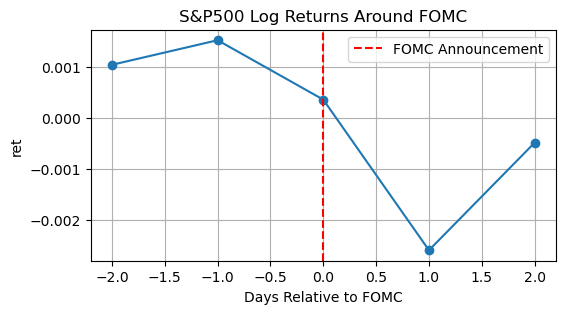

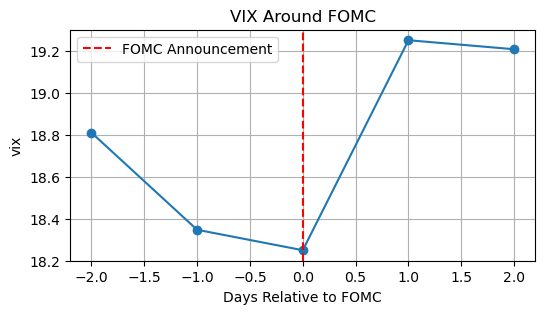

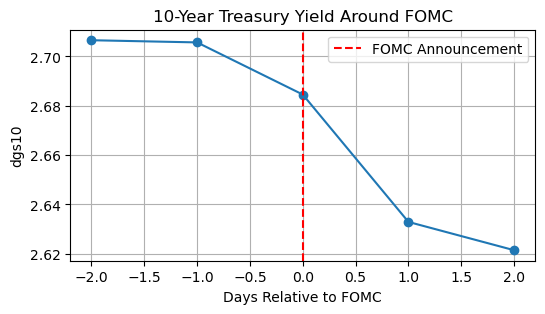

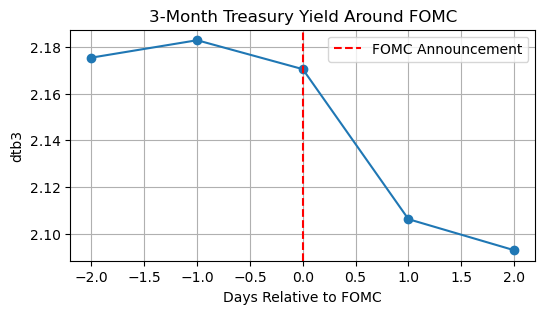

In [15]:
# Plot average reaction path of a single variable around FOMC events
def plot_event_mean(df, var, title):
    mean_path = df.groupby("event_time")[var].mean()

    plt.figure(figsize=(6,3))
    plt.plot(mean_path.index, mean_path.values, marker='o')
    plt.axvline(0, color='red', linestyle='--', label='FOMC Announcement')
    plt.title(title)
    plt.xlabel("Days Relative to FOMC")
    plt.ylabel(var)
    plt.grid(True)
    plt.legend()
    plt.show()
plot_event_mean(event_df, 'ret', "S&P500 Log Returns Around FOMC")
plot_event_mean(event_df, 'vix', "VIX Around FOMC")
plot_event_mean(event_df, 'dgs10', "10-Year Treasury Yield Around FOMC")
plot_event_mean(event_df, 'dtb3', "3-Month Treasury Yield Around FOMC")


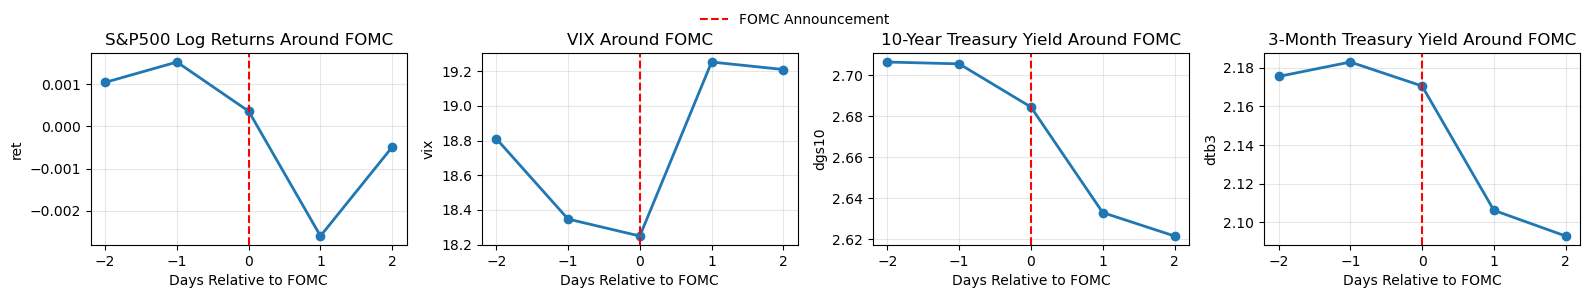

SVG saved: RQ1_event_study_four_panel.svg


In [16]:
vars_to_plot = ['ret', 'vix', 'dgs10', 'dtb3']
titles = [
    "S&P500 Log Returns Around FOMC",
    "VIX Around FOMC",
    "10-Year Treasury Yield Around FOMC",
    "3-Month Treasury Yield Around FOMC"
]

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    ax = axes[i]
    
    # compute mean reaction path
    mean_path = event_df.groupby("event_time")[var].mean()

    # plot
    ax.plot(mean_path.index, mean_path.values, marker='o', linewidth=2)
    ax.axvline(0, color='red', linestyle='--', label='FOMC Announcement')
    ax.set_title(titles[i])
    ax.set_xlabel("Days Relative to FOMC")
    ax.set_ylabel(var)
    ax.grid(True, alpha=0.3)

# one legend for all plots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig.savefig("RQ1_event_study_four_panel.svg", format="svg")
print("SVG saved: RQ1_event_study_four_panel.svg")

## RQ2

In [17]:
# Compare market reaction paths by FOMC action type
def plot_action_comparison(event_df, var, ylabel=None):
    actions = ['Hike', 'Cut', 'Hold']

    plt.figure(figsize=(9,5))

    for act in actions:
        temp = event_df[event_df['Action'] == act]
        mean_path = temp.groupby('event_time')[var].mean()
        plt.plot(
            mean_path.index, mean_path.values,
            marker='o', linewidth=2, label=act
        )

    plt.axvline(0, color='red', linestyle='--', label='FOMC Announcement')
    plt.title(f"{var.upper()} Reaction by FOMC Action Type")
    plt.xlabel("Days Relative to FOMC")
    plt.ylabel(ylabel if ylabel else var)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

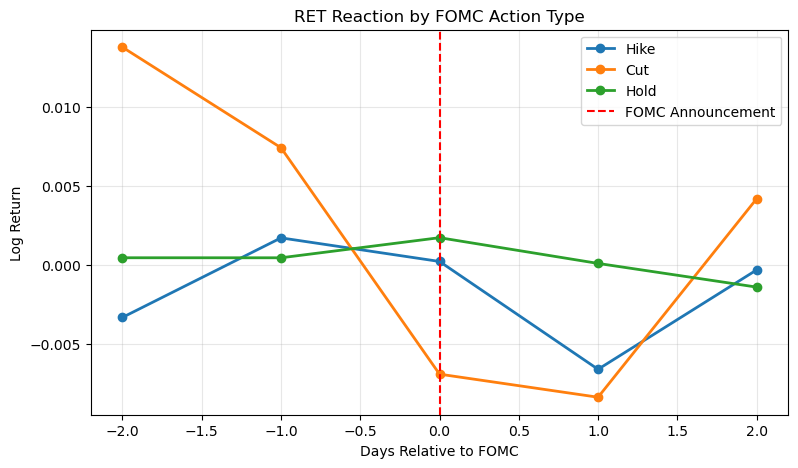

In [18]:
plot_action_comparison(event_df, 'ret', ylabel="Log Return")

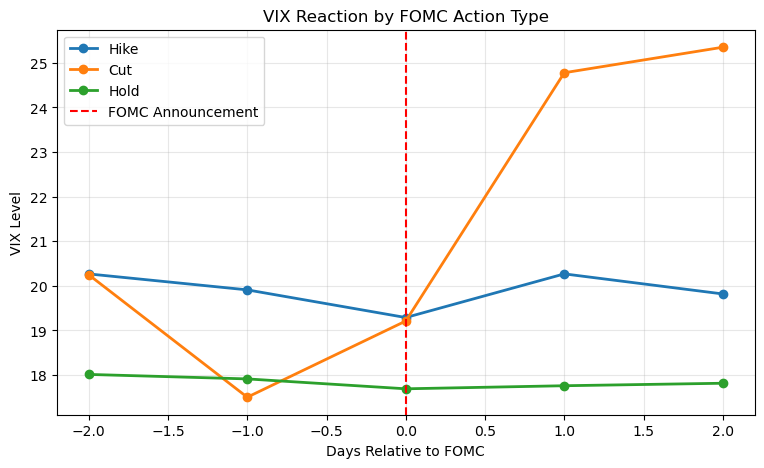

In [19]:
plot_action_comparison(event_df, 'vix', ylabel="VIX Level")

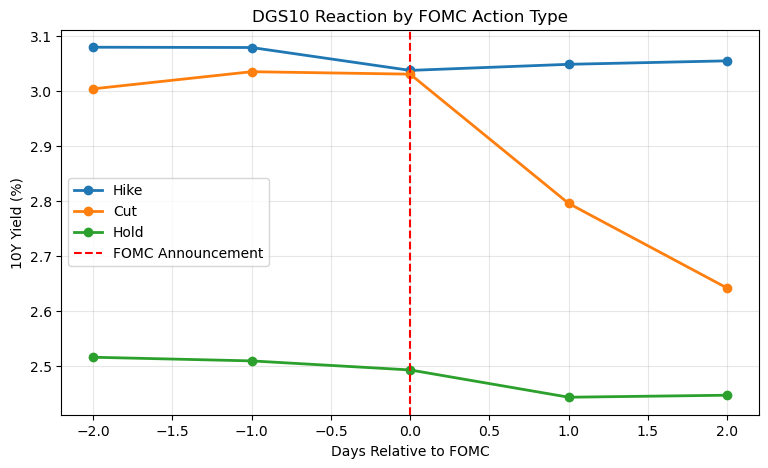

In [20]:
plot_action_comparison(event_df, 'dgs10', ylabel="10Y Yield (%)")

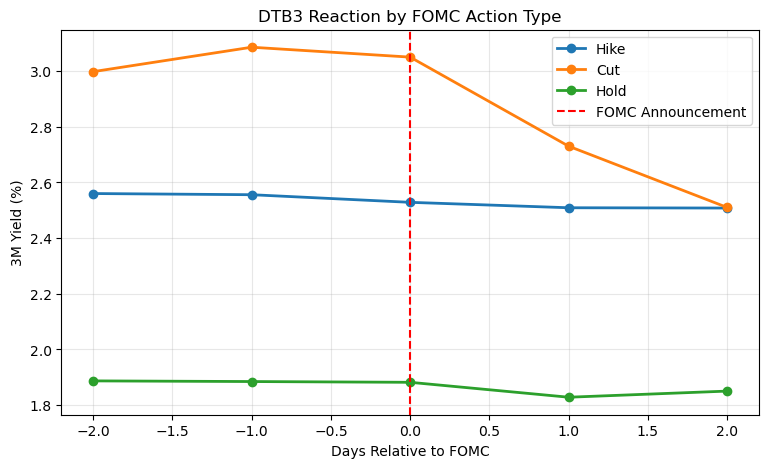

In [21]:
plot_action_comparison(event_df, 'dtb3', ylabel="3M Yield (%)")

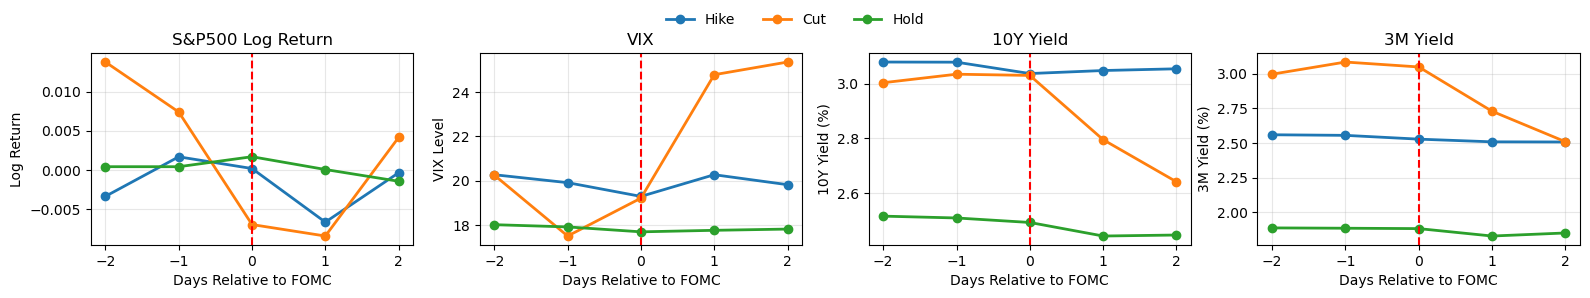

SVG saved: RQ2_event_study_by_action.svg


In [22]:
actions = ['Hike', 'Cut', 'Hold']
vars_to_plot = ['ret', 'vix', 'dgs10', 'dtb3']
titles = ['S&P500 Log Return', 'VIX', '10Y Yield', '3M Yield']
ylabels = ['Log Return', 'VIX Level', '10Y Yield (%)', '3M Yield (%)']

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    ax = axes[i]
    
    for act in actions:
        temp = event_df[event_df['Action'] == act]
        mean_path = temp.groupby("event_time")[var].mean()
        ax.plot(mean_path.index, mean_path.values, marker='o', linewidth=2, label=act)

    ax.axvline(0, color='red', linestyle='--')
    ax.set_title(titles[i])
    ax.set_xlabel("Days Relative to FOMC")
    ax.set_ylabel(ylabels[i])
    ax.grid(True, alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
fig.savefig("RQ2_event_study_by_action.svg", format="svg")
print("SVG saved: RQ2_event_study_by_action.svg")

## RQ3

In [23]:
event_df['year'] = event_df['event_date'].dt.year
event_df['high_inflation'] = event_df['year'].apply(lambda x: 1 if 2021 <= x <= 2023 else 0)# Identify high-inflation regime (2021–2023)

In [24]:
# Compare reaction paths for high inflation vs normal times
def plot_inflation_compare(event_df, var, ylabel=None):
    groups = {
        "High Inflation (2021–2023)": event_df[event_df['high_inflation'] == 1],
        "Normal Period": event_df[event_df['high_inflation'] == 0]
    }

    plt.figure(figsize=(9,5))

    for label, df in groups.items():
        mean_path = df.groupby("event_time")[var].mean()
        plt.plot(mean_path.index, mean_path.values, marker='o', linewidth=2, label=label)

    plt.axvline(0, color='red', linestyle='--')
    plt.title(f"{var.upper()} Reaction: High Inflation vs Normal")
    plt.xlabel("Days Relative to FOMC")
    plt.ylabel(ylabel if ylabel else var)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

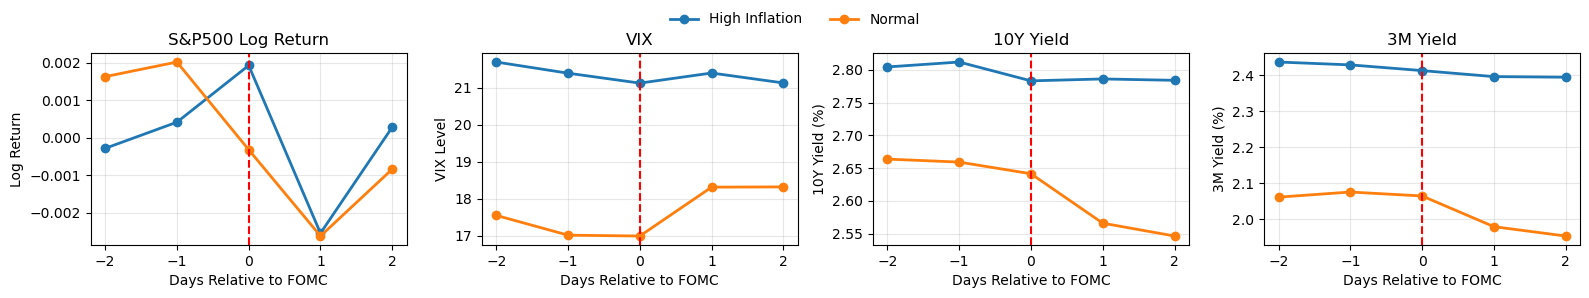

SVG saved: RQ3_high_inflation_vs_normal.svg


In [25]:
vars_to_plot = ['ret', 'vix', 'dgs10', 'dtb3']
titles = ['S&P500 Log Return', 'VIX', '10Y Yield', '3M Yield']
ylabels = ['Log Return', 'VIX Level', '10Y Yield (%)', '3M Yield (%)']

fig, axes = plt.subplots(1, 4, figsize=(16,3))
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    ax = axes[i]
    
    # High inflation
    hi = event_df[event_df['high_inflation'] == 1].groupby('event_time')[var].mean()
    ax.plot(hi.index, hi.values, marker='o', linewidth=2, label="High Inflation")
    
    # Normal period
    norm = event_df[event_df['high_inflation'] == 0].groupby('event_time')[var].mean()
    ax.plot(norm.index, norm.values, marker='o', linewidth=2, label="Normal")
    
    ax.axvline(0, color='red', linestyle='--')
    ax.set_title(titles[i])
    ax.set_xlabel("Days Relative to FOMC")
    ax.set_ylabel(ylabels[i])
    ax.grid(True, alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()
fig.savefig("RQ3_high_inflation_vs_normal.svg", format="svg")
print("SVG saved: RQ3_high_inflation_vs_normal.svg")


In [26]:
event_df['t0'] = (event_df['event_time'] == 0).astype(int)# t0 = event day dummy
event_df['high_inflation'] = event_df['event_date'].dt.year.between(2021, 2023).astype(int)

In [27]:
# Interaction regression
# Tests whether event-day reaction differs between regimes
reg_rq3 = smf.ols("ret ~ t0 * high_inflation", data=event_df).fit(cov_type="HC3")
print(reg_rq3.summary())

                            OLS Regression Results                            
Dep. Variable:                    ret   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.2041
Date:                Fri, 12 Dec 2025   Prob (F-statistic):              0.894
Time:                        16:04:38   Log-Likelihood:                 1123.7
No. Observations:                 392   AIC:                            -2239.
Df Residuals:                     388   BIC:                            -2223.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          5.821e-05      0.00

In [28]:
# Create previous day return
event_df = event_df.sort_values(['event_date', 'event_time'])
event_df['ret_lag'] = event_df.groupby('event_date')['ret'].shift(1)
df_ml = event_df[event_df['t0'] == 1].copy()

# Convert Action to category (Hike=1, Cut=-1, Hold=0)
df_ml['action_label'] = df_ml['Action'].map({'Hike':1, 'Cut':-1, 'Hold':0})

X = df_ml[[
    'vix', 
    'ret_lag',
    'dgs10', 
    'dtb3',
    'high_inflation'
]]

y = df_ml['action_label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

logit = LogisticRegression(multi_class='multinomial', max_iter=500)
logit.fit(X_train, y_train)
y_pred_logit = logit.predict(X_test)

print("Logistic Accuracy:", accuracy_score(y_test, y_pred_logit))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_logit))

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

Logistic Accuracy: 0.6666666666666666
Confusion Matrix:
 [[ 0  3  1]
 [ 0 13  3]
 [ 0  1  3]]
KNN Accuracy: 0.625
KNN Confusion Matrix:
 [[ 0  4  0]
 [ 0 13  3]
 [ 0  2  2]]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
